# Lap-Rep (Laplacian Representation)

In [1]:
from neuronav.envs.grid_env import GridEnv, GridSize, GridObsType, GridTopography, OrientationType
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np
import torch
import torch.nn as nn

/Users/awjuliani/miniconda3/lib/python3.8/site-packages/matplotlib_inline/config.py:66: DeprecationWarning: InlineBackend._figure_formats_changed is deprecated in traitlets 4.1: use @observe and @unobserve instead.
  def _figure_formats_changed(self, name, old, new):


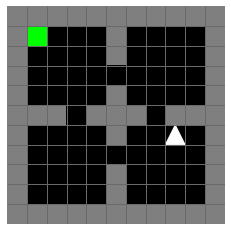

In [2]:
env = GridEnv(obs_type=GridObsType.twohot, topography=GridTopography.four_rooms, grid_size=GridSize.small, orientation_type=OrientationType.dynamic)
obs = env.reset(random_start=True)
env.render()

In [3]:
def collect_steps(num_steps, num_eps):
    obs_pairs = []
    locations = []
    for j in range(num_eps):
        obs = env.reset(random_start=True)
        for i in range(num_steps):
            locations.append(env.agent_pos)
            new_obs, _, _, _ = env.step(env.action_space.sample())
            obs_pairs.append(np.array([obs, new_obs]))
            obs = new_obs
    obs_pairs = torch.tensor(np.stack(obs_pairs)).type(torch.float32)
    return obs_pairs, np.array(locations)

In [4]:
class lap_network(nn.Module):
    def __init__(self, in_size, h_size, out_size):
        super().__init__()

        self.proj = nn.Sequential(
            nn.Linear(in_size, h_size),
            nn.Tanh(),
        )

        self.lap_map = nn.Sequential(
            nn.Linear(h_size, h_size),
            nn.GELU(),
            nn.Linear(h_size, out_size),
            nn.Sigmoid()
        )

        self.optimizer = torch.optim.AdamW(self.parameters(), lr=1e-4)

    def forward(self, x):
        h =  10 * self.proj(x).detach()
        h = self.lap_map(h)
        return h

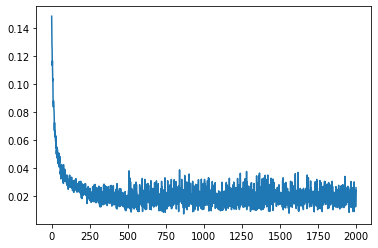

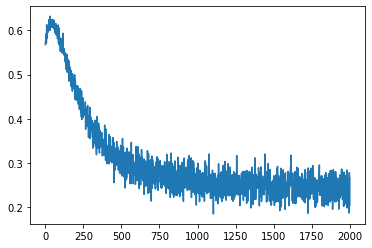

In [5]:
num_epoch = 2000
agent_steps = 5
agent_episodes = 40

embed_size = 25
h_size = 128

net = lap_network(env.observation_space.shape[0], h_size, embed_size)
losses = []
for i in range(num_epoch):
    net.optimizer.zero_grad()
    obs, _ = collect_steps(agent_steps, agent_episodes)
    embed = net(obs)
    a = embed[:,0]
    b = embed[:,1]
    s_a = a[torch.randperm(a.size()[0])]
    s_b = b[torch.randperm(b.size()[0])]

    attract_term = torch.linalg.norm(a - b, dim=-1).pow(2).mean()
    repel_term = torch.exp(-torch.linalg.norm(s_a - s_b, dim=-1)).mean()
    loss = 1 * attract_term + 0.2 * repel_term
    losses.append([attract_term.detach(), repel_term.detach()])
    loss.backward()
    net.optimizer.step()
a_loss, r_loss = zip(*losses)
plt.plot(a_loss)
plt.show()
plt.plot(r_loss)
plt.show()

Text(0.5, 1.0, 'Euclidean structure')

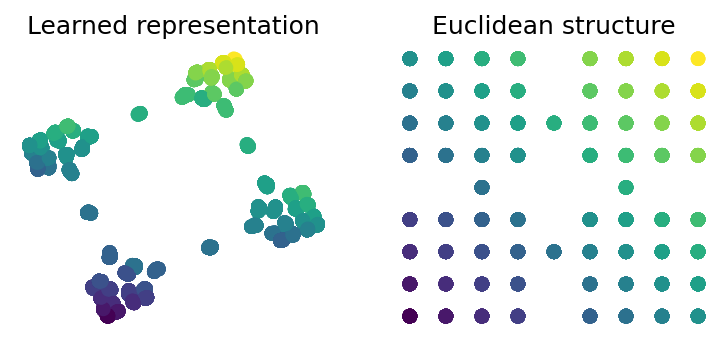

In [6]:
obs, locs = collect_steps(100, 50)
locs_n = np.array(locs) / (env.grid_size - 1)
scale = locs_n.sum(axis=-1) / 2
embed = net(obs)
a = embed[:,0].detach()
pca = PCA(n_components=2)
z = pca.fit_transform(a)

fig, axs = plt.subplots(1, 2, figsize=(6, 2.5), dpi=150)
axs[0].scatter(z[:,0], z[:,1], c=scale)
_ = axs[0].axis("off")
axs[0].set_title("Learned representation")
axs[1].scatter(locs_n[:,0], locs_n[:,1], c=scale)
_ = axs[1].axis("off")
axs[1].set_title("Euclidean structure")

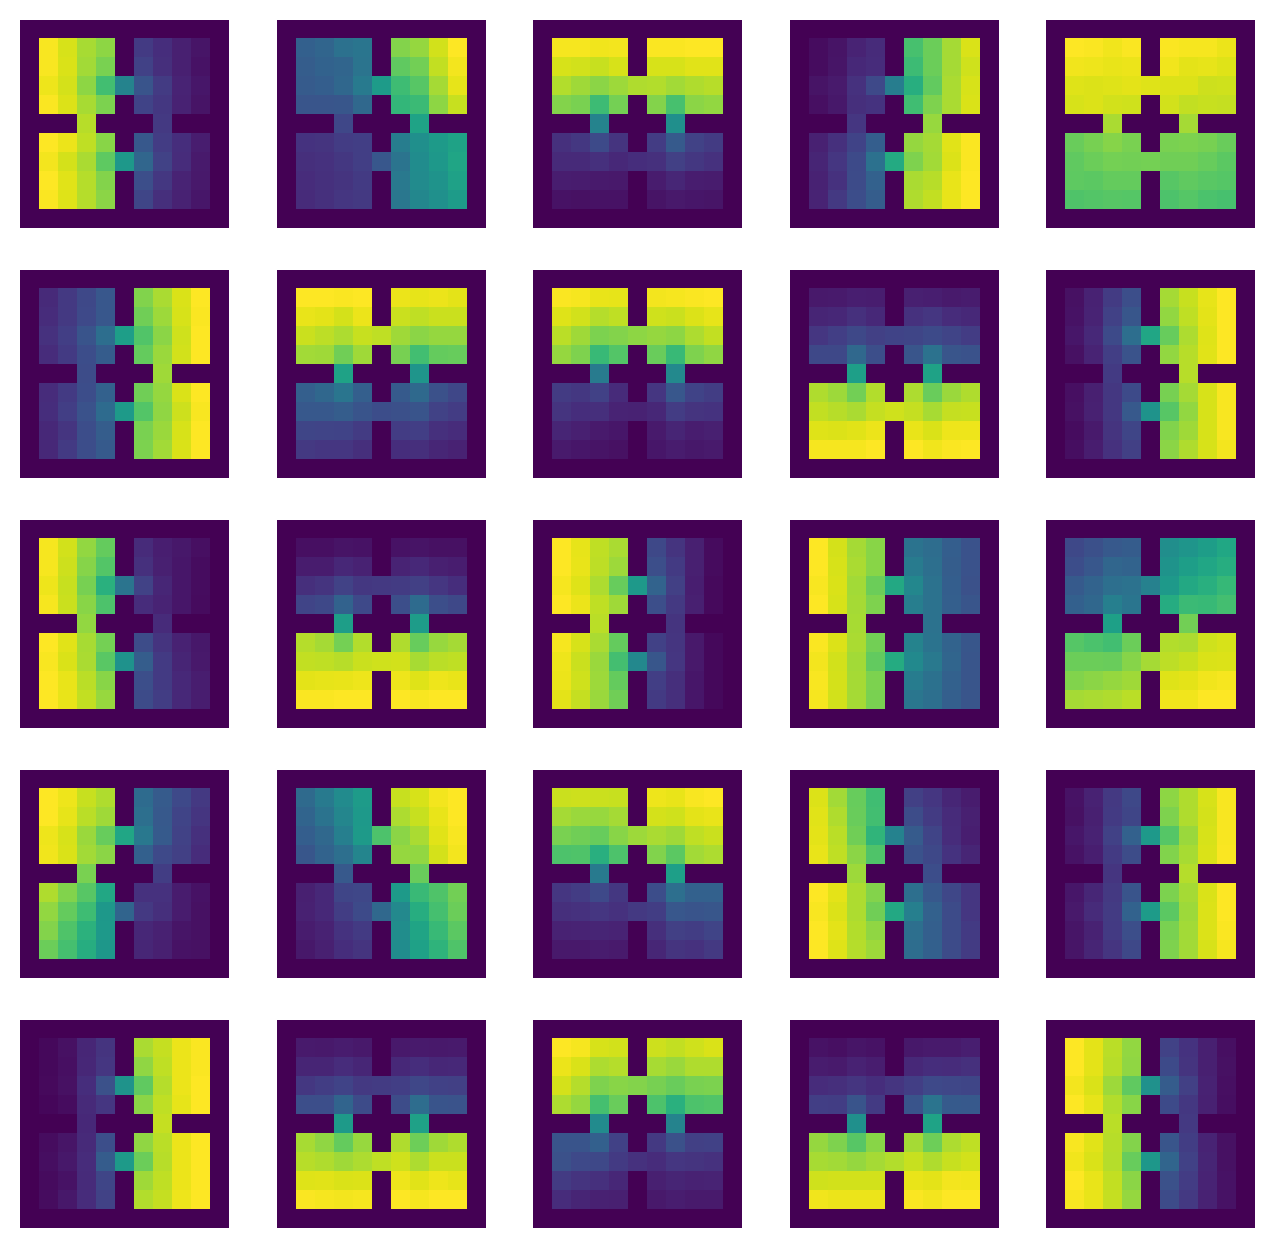

In [7]:
row_num = int(np.sqrt(embed_size))

fig, axs = plt.subplots(row_num, row_num, figsize=(8, 8), dpi=200)

for j in range(embed_size):
    x = j // row_num
    y = j % row_num
    grid = torch.zeros(env.grid_size, env.grid_size)
    for i in range(len(a)):
        grid[locs[i,0], locs[i,1]] = a[i,j]
    axs[x,y].imshow(grid)
    axs[x,y].axis("off")